<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/demos/day19_demo_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 19 Demo: Deep Learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf


## Check for GPU
Deep learning can be slow running on a CPU.

In Google Colab, you can change the runtime type under the Runtime menu to be a GPU or TPU, which will help speed things up.

To see if the code is running on a GPU, check for CUDA as shown below. CUDA (Compute Unified Device Architecture) is NVIDIA's GPU computing platform.

In [2]:
# Check for GPUs
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPUs Found: {len(gpus)}")
    for gpu in gpus:
        print(f" - {gpu}")
else:
    print("No GPU detected. TensorFlow is running on CPU.")

GPUs Found: 1
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## Creating tensors
We typically won't create tensors like this, but it helps to know the vocabulary and how things work.

In [3]:
# 0-dimensional (scalar)
A = tf.constant(1)
print(f"Scalar Shape: {A.shape}")

# 1-dimensional (vector)
B = tf.constant([1, 2, 3])
print(f"Vector Shape: {B.shape}")

# 2-dimensional (matrix)
C = tf.constant([[1, 2],
                 [3, 4]])
print(f"Matrix Shape: {C.shape}")

Scalar Shape: ()
Vector Shape: (3,)
Matrix Shape: (2, 2)


## Full example

In [4]:
# iris data
file_link = 'https://drive.google.com/uc?export=download&id=1UZTj2GjSTFiBqAeOXiroTxviy_zLxLpL'
df = pd.read_csv(file_link)
display(df.head())

# whatever.values turns the variable into a numpy array
X = df.drop(columns=['class']).values

# Ordinal encode the classes (0, 1, 2)
le = LabelEncoder()
y = le.fit_transform(df['class'])

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=1)

# Neural nets can be sensitive to data scale
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

# define the architecture
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)), # input shape must match data columns
    tf.keras.layers.Dense(16, activation='relu'), # hidden layer 1
    tf.keras.layers.Dense(8, activation='relu'), # hidden layer 2
    tf.keras.layers.Dense(3, activation='softmax') # outputs should match number of classes
])

opt = tf.keras.optimizers.Adam(learning_rate=0.001)

# sparse categorical crossentropy means the target labels are ordinal encoded
# and not one-hot encoded.
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# training loop
history = model.fit(Xtrain, ytrain, epochs=100, batch_size=8, validation_split=0.2)

history

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4583 - loss: 1.2650 - val_accuracy: 0.4167 - val_loss: 1.1905
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4792 - loss: 1.1707 - val_accuracy: 0.3750 - val_loss: 1.1414
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4792 - loss: 1.0943 - val_accuracy: 0.3750 - val_loss: 1.0947
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4688 - loss: 1.0300 - val_accuracy: 0.3750 - val_loss: 1.0535
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4688 - loss: 0.9693 - val_accuracy: 0.3750 - val_loss: 1.0131
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4792 - loss: 0.9188 - val_accuracy: 0.3750 - val_loss: 0.9732
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4896 - loss: 0.8769 - val_accuracy: 0.3750 - val_loss: 0.9430
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4896 - loss: 0.8395 - val_accuracy: 0.3750 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step


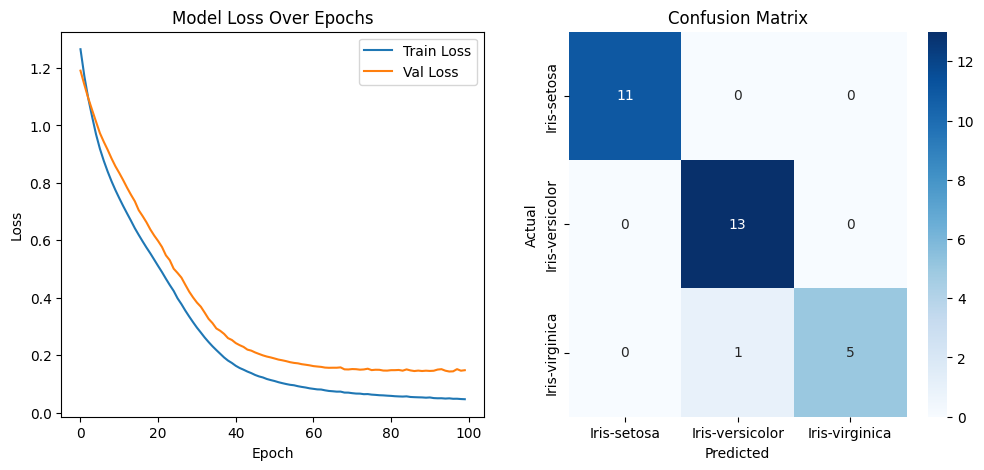

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.93      1.00      0.96        13
           2       1.00      0.83      0.91         6

    accuracy                           0.97        30
   macro avg       0.98      0.94      0.96        30
weighted avg       0.97      0.97      0.97        30



In [5]:
# loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# confusion matrix
plt.subplot(1, 2, 2)

# note that the model has 3 outputs, which are probabilities for the classes
ypred_probs = model.predict(Xtest)

# Convert probs back to class index
ypred = np.argmax(ypred_probs, axis=1)

cm = confusion_matrix(ytest, ypred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Evaluate the test data
print(classification_report(ytest, ypred))

## How many trainable parameters are in this network?
- For the first hidden layer, each of the 16 neurons has a weight for each of the 4 inputs, and each of the 16 neurons has 1 weight for bias = 16*4 + 16 = 80.
- For the second hidden layer, each of the 8 neurons has a weight for each of the 16 outputs from the prior layer, plus 8 more biases = 8*16 + 8 = 136.
- For the output layer, the 3 neurons have a weight for each of the 8 inputs plus 3 bias = 27.

Total trainable parameters = 80 + 136 + 27 = 243

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 731 (2.86 KB)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 488 (1.91 KB)

In [7]:
# pass in two rows of data with 4 features (columns)
data = [[ 0.3, -0.1,  0.4,  0.2],
        [-1.2,  0.9, -1.2, -1.2]]
data = np.array(data)
out = model(data)
print(out)

tf.Tensor(
[[1.3657151e-03 9.7568589e-01 2.2948395e-02]
 [9.9661237e-01 3.3865918e-03 1.1115012e-06]], shape=(2, 3), dtype=float32)


In [8]:
# to make a prediction from the raw outputs,
# we choose the highest
pred = np.argmax(out, axis=1)
pred

array([1, 0])

In [9]:
# we could use our label encoder to transform ordinal encodings back to strings
le.inverse_transform(pred)

array(['Iris-versicolor', 'Iris-setosa'], dtype=object)